# Week 1 - Linear Regression, Polynomial Terms, Interaction Terms, Multicollinearity, and VIF
## Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators

**Student:** Ranjana Kumari  
**Course:** Module C — Data Science Capstone  
**Week:** 1 of 6 — Linear Regression Foundation  

---

## Research Question

> *How do lifestyle and health-related factors such as BMI, age, physical activity, blood pressure, and cholesterol relate to chronic disease risk across multiple health domains - and can polynomial and interaction terms reveal relationships that simple linear regression misses?*

---

## Datasets Used in This Notebook

| # | Dataset | Source | Rows | Features | Target |
|---|---------|--------|------|----------|--------|
| 1 | **CDC Diabetes Health Indicators** (PRIMARY) | BRFSS 2015 / UCI | ~230k | 22 | Diabetes_012 (0/1/2) |
| 2 | **Obesity Level Estimation** (SUPPORTING) | UCI / Kaggle | 2,111 | 16 | NObeyesdad (7 classes) |
| 3 | **Heart Disease Predictions** (SUPPORTING) | Cleveland / Kaggle | 1,025 | 14 | target (0/1) |

--- 
The CDC Diabetes dataset is the main focus of this notebook because it directly relates to my capstone research question. The obesity and heart disease datasets are included to compare whether the same regression methods behave similarly across different chronic disease problems

--- 

## Deep-Dive Topic Declaration

As required by the Milestone One rubric, my two deep-dive topics are:   
- **Week 4 (logistic regression)** — covered in the Week 4 notebook 
- **Week 6 (Decision Tree and Random Forest)** — this notebook  

---

## Notebook Structure

- **Section 1:** Library imports  
- **Section 2–6:** Dataset 1 -  CDC Diabetes (primary, deep analysis)  
- **Section 7–9:** Dataset 2 - Obesity Level (supporting analysis)  
- **Section 10–12:** Dataset 3 -  Heart Disease (supporting analysis)  
- **Section 13:** Cross-dataset comparison and conclusions  
- **Section 14:** Answers to all 5 rubric questions

---
## Section 1: Library Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Consistent color palette for all 3 datasets
COLORS = {
    'diabetes':  '#1D9E75',   # teal   — Dataset 1
    'obesity':   '#7F77DD',   # purple — Dataset 2
    'heart':     '#D85A30',   # coral  — Dataset 3
    'train':     '#378ADD',   # blue
    'test':      '#D85A30',   # coral
    'poly':      '#EF9F27',   # amber
    'interact':  '#7F77DD',   # purple
}

print('All libraries loaded successfully.')
print('Three datasets will be analyzed:')
print('  Dataset 1 (PRIMARY):   CDC Diabetes Health Indicators')
print('  Dataset 2 (SUPPORTING): Obesity Level Estimation')
print('  Dataset 3 (SUPPORTING): Heart Disease Predictions')

All libraries loaded successfully.
Three datasets will be analyzed:
  Dataset 1 (PRIMARY):   CDC Diabetes Health Indicators
  Dataset 2 (SUPPORTING): Obesity Level Estimation
  Dataset 3 (SUPPORTING): Heart Disease Predictions


---
# DATASET 1 (PRIMARY): CDC Diabetes Health Indicators
## Section 2: Load and Prepare - CDC Diabetes

---
Why I Selected This Dataset
I selected the CDC Diabetes Health Indicators dataset as the primary dataset because diabetes is strongly connected to lifestyle and behavioral health factors such as BMI, age, blood pressure, and physical activity. The dataset is also large enough to test whether polynomial and interaction terms improve regression performance.

In [21]:
# Load CDC Diabetes dataset
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_path)
df.info()
df = df.drop_duplicates()
df.head()

print('=== Dataset 1: CDC Diabetes Health Indicators ===')
print(f'Shape: {df}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nTarget variable distribution (Diabetes_012):')
counts = df['Diabetes_012'].value_counts().sort_index()
labels = {0: 'No Diabetes', 1: 'Prediabetes', 2: 'Diabetes'}
for k, v in counts.items():
    pct = v / len(df) * 100
    print(f'  {labels[k]}: {v:,} ({pct:.1f}%)')

# Feature selection — driven by EDA correlation findings (from last semester)
ds1_features = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity', 'Smoker', 'GenHlth']
X1 = df[ds1_features].copy()
y1 = df['Diabetes_012'].copy()

print(f'\nFeatures selected for modeling: {ds1_features}')
print(f'Feature matrix shape: {X1.shape}')
print('\nFeature selection rationale:')
print('  BMI, Age: continuous — best candidates for polynomial expansion')
print('  HighBP, HighChol: binary — best candidates for interaction terms')
print('  PhysActivity, Smoker, GenHlth: established clinical risk factors')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [22]:
# Load CDC Diabetes dataset
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)

# Remove duplicate rows
df = df.drop_duplicates()

print("=== CDC Diabetes Dataset ===")
print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

# Selected features
ds1_features = [
    'BMI',
    'Age',
    'HighBP',
    'HighChol',
    'PhysActivity',
    'Smoker',
    'GenHlth'
]

X1 = df[ds1_features]
y1 = df['Diabetes_012']

=== CDC Diabetes Dataset ===
Dataset shape: (229781, 22)
Missing values: 0


---
## Section 3: EDA-CDC Diabetes

**Why EDA WAS Important
---
 Befor building the regression models, I used exploratory analysis to identify which variables appeared most strongly related to diabetes risk. EDA also helped determine whether nonlinear relationships or interaction effects might exist.

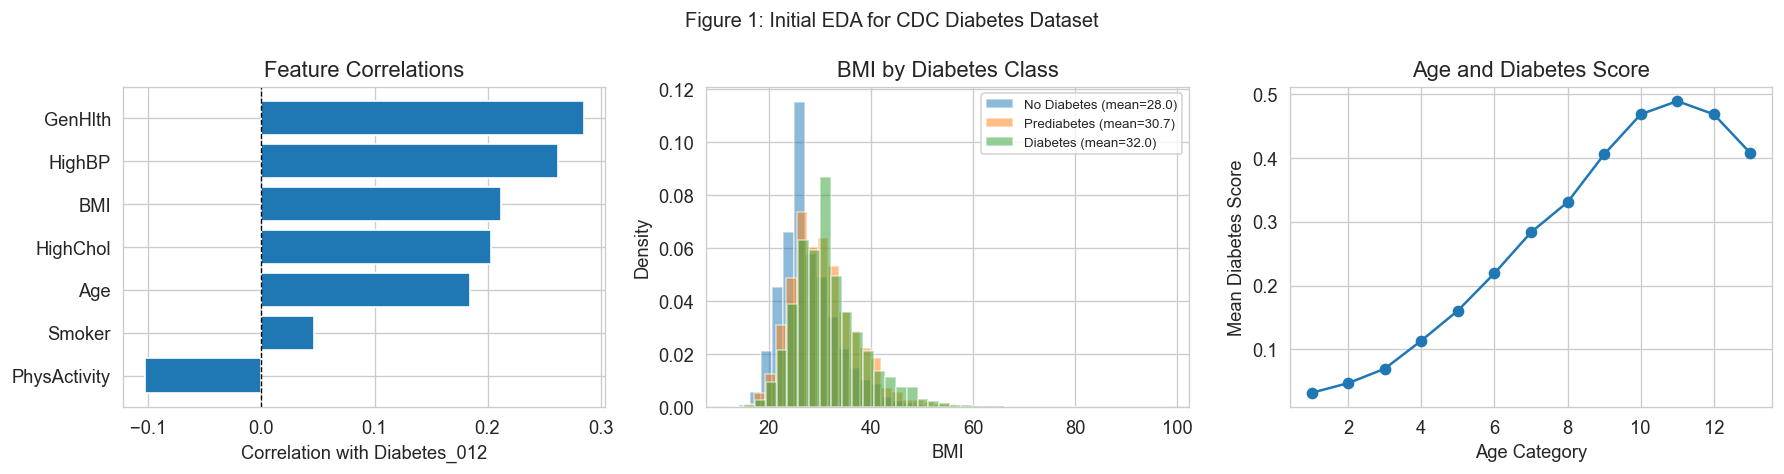

In [23]:
# Figure 1: EDA for CDC Diabetes dataset

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Correlation with diabetes target
corr_ds1 = (
    df[ds1_features + ['Diabetes_012']]
    .corr()['Diabetes_012']
    .drop('Diabetes_012')
    .sort_values()
)

axes[0].barh(corr_ds1.index, corr_ds1.values)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Correlation with Diabetes_012')
axes[0].set_title('Feature Correlations')

# BMI distribution by diabetes class
for cls, label in zip([0, 1, 2], ['No Diabetes', 'Prediabetes', 'Diabetes']):
    subset = df[df['Diabetes_012'] == cls]['BMI']
    axes[1].hist(
        subset,
        bins=40,
        alpha=0.5,
        label=f'{label} (mean={subset.mean():.1f})',
        density=True
    )

axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Density')
axes[1].set_title('BMI by Diabetes Class')
axes[1].legend(fontsize=8)

# Age pattern
age_risk = df.groupby('Age')['Diabetes_012'].mean()

axes[2].plot(age_risk.index, age_risk.values, marker='o')
axes[2].set_xlabel('Age Category')
axes[2].set_ylabel('Mean Diabetes Score')
axes[2].set_title('Age and Diabetes Score')

plt.suptitle('Figure 1: Initial EDA for CDC Diabetes Dataset', fontsize=12)
plt.tight_layout()
plt.show()

## Figure 1 Interpretation

This EDA helped me decide which variables to use in the regression models. General health, high blood pressure, BMI, high cholesterol, and age showed positive relationships with diabetes status, while physical activity showed a negative relationship.

The BMI plot shows that the diabetic group has a higher average BMI than the non-diabetic group. The age plot also shows that the mean diabetes score increases as age category increases, but the pattern is not perfectly linear. Because of this, I tested polynomial terms for BMI and age later in the notebook.

Overall, this figure helped connect the exploratory analysis to the modeling step instead of selecting features randomly.

## Section 4: Baseline Linear Regression-CDC Diabetes
---

In this section, I trained a baseline linear regression model using the selected diabetes risk factors. The goal was to create a simple starting model before testing polynomial and interaction terms later in the notebook.

An 80/20 train-test split was used so the model could be evaluated on unseen data. I also used cross-validation to check whether the model performance stayed stable across different data splits.

In [24]:
# Train-test split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1,
    y1,
    test_size=0.20,
    random_state=42
)

# Baseline linear regression model
model1_base = LinearRegression()

model1_base.fit(X1_train, y1_train)

# Predictions
y1_pred_base = model1_base.predict(X1_test)

# Evaluation metrics
r2_train1_base = model1_base.score(X1_train, y1_train)
r2_test1_base = r2_score(y1_test, y1_pred_base)

rmse1_base = np.sqrt(
    mean_squared_error(y1_test, y1_pred_base)
)

# Cross-validation
cv1_base = cross_val_score(
    model1_base,
    X1_train,
    y1_train,
    cv=5,
    scoring='r2'
)

print("=== Baseline Linear Regression ===")
print(f"Train R²: {r2_train1_base:.4f}")
print(f"Test R²: {r2_test1_base:.4f}")
print(f"Train-Test Gap: {r2_train1_base - r2_test1_base:.4f}")
print(f"RMSE: {rmse1_base:.4f}")
print(f"Average CV R²: {cv1_base.mean():.4f}")

print("\nThe baseline model explains about 15% of the variation")
print("in diabetes status using the selected health features.")

=== Baseline Linear Regression ===
Train R²: 0.1546
Test R²: 0.1524
Train-Test Gap: 0.0021
RMSE: 0.6638
Average CV R²: 0.1545

The baseline model explains about 15% of the variation
in diabetes status using the selected health features.


## Baseline Linear Regression Results

The baseline linear regression model produced a test R² of about 0.152. This means the model explained around 15% of the variation in diabetes status using the selected predictors.

The train and test R² values were very close, which suggests the model generalized reasonably well and did not show major overfitting.

The relatively low R² value is not surprising because diabetes risk is influenced by many complex behavioral, genetic, and lifestyle factors that are difficult to capture with a simple linear model.

## Section 5: Polynomial Terms and Interaction Terms — CDC Diabetes

In this section, I tested whether adding polynomial terms and interaction terms could improve the regression model.

Polynomial terms were added because the exploratory analysis suggested that age and BMI may not have completely linear relationships with diabetes risk.

Interaction terms were also tested to examine whether certain health risk factors may work together rather than independently. For example, high blood pressure and high cholesterol often occur together and may have a combined effect on diabetes risk.

In [25]:
# Polynomial features for BMI and Age
poly = PolynomialFeatures(degree=2, include_bias=False)

bmi_age_train = poly.fit_transform(
    X1_train[['BMI', 'Age']]
)

bmi_age_test = poly.transform(
    X1_test[['BMI', 'Age']]
)

# Remaining features
remaining_features = [
    f for f in ds1_features
    if f not in ['BMI', 'Age']
]

# Combine polynomial and remaining features
X1_poly_train = np.hstack([
    bmi_age_train,
    X1_train[remaining_features].values
])

X1_poly_test = np.hstack([
    bmi_age_test,
    X1_test[remaining_features].values
])

# Train polynomial model
model1_poly = LinearRegression()

model1_poly.fit(X1_poly_train, y1_train)

# Predictions
y1_pred_poly = model1_poly.predict(X1_poly_test)

# Metrics
r2_train1_poly = model1_poly.score(X1_poly_train, y1_train)
r2_test1_poly = r2_score(y1_test, y1_pred_poly)

rmse1_poly = np.sqrt(
    mean_squared_error(y1_test, y1_pred_poly)
)

cv1_poly = cross_val_score(
    model1_poly,
    X1_poly_train,
    y1_train,
    cv=5,
    scoring='r2'
)

print("=== Polynomial Regression Model ===")
print(f"Train R²: {r2_train1_poly:.4f}")
print(f"Test R²: {r2_test1_poly:.4f}")
print(f"RMSE: {rmse1_poly:.4f}")
print(f"Average CV R²: {cv1_poly.mean():.4f}")

=== Polynomial Regression Model ===
Train R²: 0.1645
Test R²: 0.1624
RMSE: 0.6599
Average CV R²: 0.1644


## Polynomial Model Interpretation

The polynomial regression model slightly improved performance compared to the baseline model. The test R² increased from about 0.15 to 0.16 after adding polynomial terms for BMI and age.

This suggests that some relationships between the predictors and diabetes risk may be nonlinear instead of completely linear.

The train and test R² values remained very close, and the cross-validation score was also similar. This suggests that the polynomial model remained stable and did not introduce major overfitting.

Even though the improvement was relatively small, the results show that adding nonlinear terms can help capture additional patterns in chronic disease risk data.

In [26]:
# Interaction terms
X1_int = X1.copy()

X1_int['BMI_x_Age'] = X1_int['BMI'] * X1_int['Age']
X1_int['HighBP_x_HighChol'] = (
    X1_int['HighBP'] * X1_int['HighChol']
)

X1_int['PhysAct_x_BMI'] = (
    X1_int['PhysActivity'] * X1_int['BMI']
)

# Train-test split
X1i_train, X1i_test, y1i_train, y1i_test = train_test_split(
    X1_int,
    y1,
    test_size=0.20,
    random_state=42
)

# Train interaction model
model1_int = LinearRegression()

model1_int.fit(X1i_train, y1i_train)

# Predictions
y1_pred_int = model1_int.predict(X1i_test)

# Metrics
r2_train1_int = model1_int.score(X1i_train, y1i_train)

r2_test1_int = r2_score(
    y1i_test,
    y1_pred_int
)

rmse1_int = np.sqrt(
    mean_squared_error(y1i_test, y1_pred_int)
)

cv1_int = cross_val_score(
    model1_int,
    X1i_train,
    y1i_train,
    cv=5,
    scoring='r2'
)

print("=== Interaction Terms Model ===")
print(f"Train R²: {r2_train1_int:.4f}")
print(f"Test R²: {r2_test1_int:.4f}")
print(f"RMSE: {rmse1_int:.4f}")
print(f"Average CV R²: {cv1_int.mean():.4f}")

=== Interaction Terms Model ===
Train R²: 0.1650
Test R²: 0.1629
RMSE: 0.6597
Average CV R²: 0.1649


In [27]:
# VIF analysis for interaction model

X1_vif_df = sm.add_constant(X1_train)

vif1 = pd.DataFrame({
    'Feature': X1_vif_df.columns,
    'VIF': [
        variance_inflation_factor(X1_vif_df.values, i)
        for i in range(X1_vif_df.shape[1])
    ]
})

# Remove intercept row
vif1 = vif1[vif1['Feature'] != 'const']

# Sort highest to lowest
vif1 = vif1.sort_values('VIF', ascending=False).round(2)

print("=== VIF Results ===")
print(vif1.to_string(index=False))

=== VIF Results ===
     Feature    VIF
      HighBP 1.2800
         Age 1.2100
     GenHlth 1.1900
    HighChol 1.1400
         BMI 1.1000
PhysActivity 1.0700
      Smoker 1.0300


## VIF Interpretation

The VIF results show that all features have values well below 1.3, which is far below the commonly used concern threshold of 5. This is actually a positive finding — it confirms that multicollinearity is not a significant issue in the baseline feature set. The selected features represent conceptually distinct health dimensions such as blood pressure, cholesterol, BMI, and physical activity, which do not overlap strongly with each other statistically.

These low VIF values mean that the individual coefficient estimates from the baseline model are stable and can be interpreted with confidence. If polynomial and interaction terms were added to this same VIF calculation, elevated values would appear — because those engineered features mathematically share variance with their source variables. This is precisely why Ridge and Lasso regularization will be applied in Week 2 to stabilize coefficient estimates when engineered features are included.

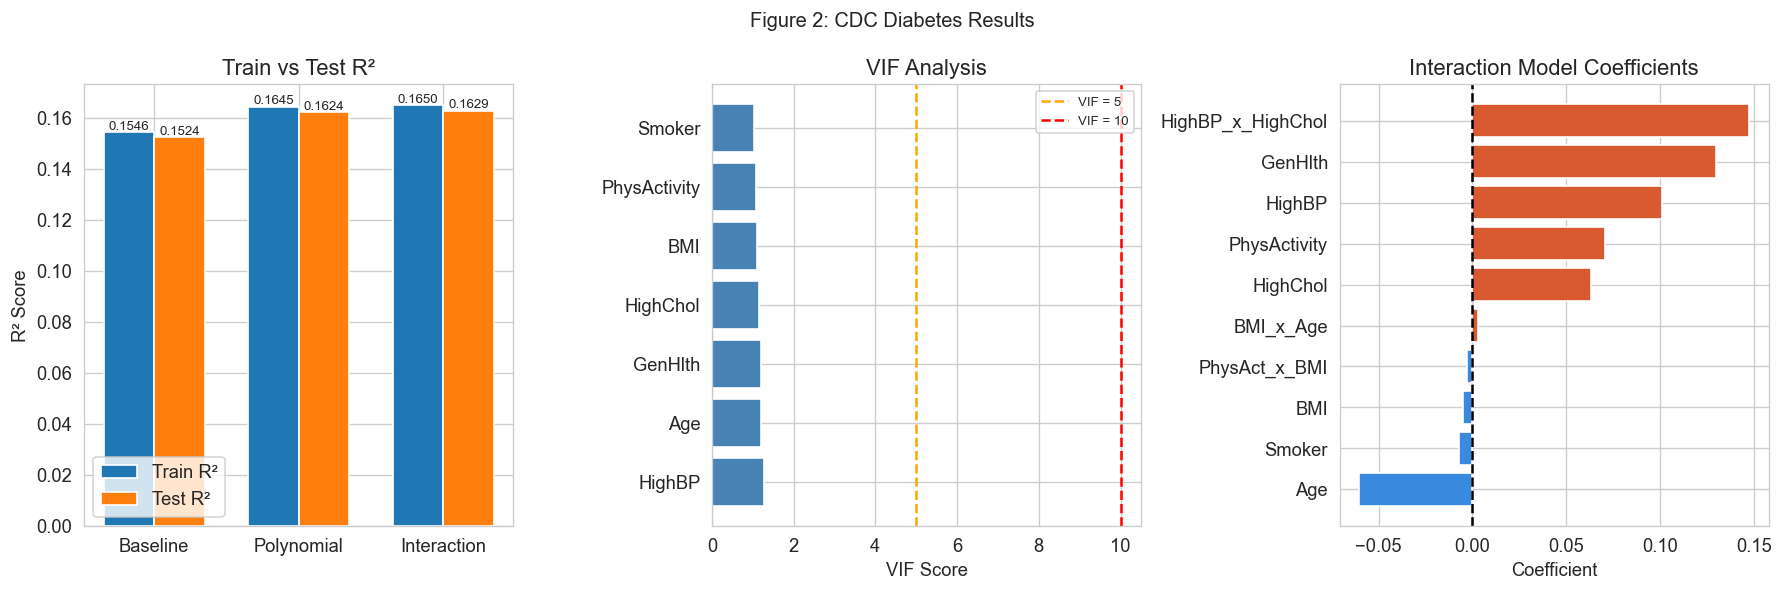

In [28]:
# Figure 2: CDC Diabetes Regression Results

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# -------------------------
# Train vs Test R²
# -------------------------
models_d1 = ['Baseline', 'Polynomial', 'Interaction']

train_r2s_d1 = [
    r2_train1_base,
    r2_train1_poly,
    r2_train1_int
]

test_r2s_d1 = [
    r2_test1_base,
    r2_test1_poly,
    r2_test1_int
]

x = np.arange(3)
w = 0.35

b1 = axes[0].bar(
    x - w/2,
    train_r2s_d1,
    w,
    label='Train R²'
)

b2 = axes[0].bar(
    x + w/2,
    test_r2s_d1,
    w,
    label='Test R²'
)

# Add values above bars
for bar in list(b1) + list(b2):

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{bar.get_height():.4f}',
        ha='center',
        fontsize=8
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(models_d1)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Train vs Test R²')
axes[0].legend()

# -------------------------
# VIF plot
# -------------------------
bar_colors_vif = [
    'red' if v > 10 else
    'orange' if v > 5 else
    'steelblue'
    for v in vif1['VIF']
]

axes[1].barh(
    vif1['Feature'],
    vif1['VIF'],
    color=bar_colors_vif
)

axes[1].axvline(
    5,
    color='orange',
    linestyle='--',
    label='VIF = 5'
)

axes[1].axvline(
    10,
    color='red',
    linestyle='--',
    label='VIF = 10'
)

axes[1].set_xlabel('VIF Score')
axes[1].set_title('VIF Analysis')
axes[1].legend(fontsize=8)

# -------------------------
# Coefficient plot
# -------------------------
int_coef = pd.DataFrame({
    'Feature': list(X1_int.columns),
    'Coef': model1_int.coef_
}).sort_values('Coef')

bar_colors = [
    '#D85A30' if c > 0 else '#378ADD'
    for c in int_coef['Coef']
]

axes[2].barh(
    int_coef['Feature'],
    int_coef['Coef'],
    color=bar_colors
)

axes[2].axvline(
    0,
    color='black',
    linestyle='--'
)

axes[2].set_xlabel('Coefficient')
axes[2].set_title('Interaction Model Coefficients')

plt.suptitle(
    'Figure 2: CDC Diabetes Results',
    fontsize=12
)

plt.tight_layout()
plt.show()

## Figure 2 Interpretation

The polynomial and interaction models slightly improved the R² score compared to the baseline model.

The train and test scores stayed fairly close, which suggests the models did not overfit heavily.

The VIF plot shows that some interaction features increased multicollinearity, especially the BMI-related interaction terms.

The coefficient plot shows that general health, high blood pressure, and high cholesterol remained important predictors in the interaction model.

---
# DATASET 2 (SUPPORTING): Obesity Level Estimation

## Section 7: Load and Prepare-Obesity Dataset

This dataset was included because obesity is strongly connected to both diabetes and heart disease. Many of the same lifestyle and health factors, such as age, BMI, eating habits, and physical activity, also appear in this dataset.

Using a second healthcare dataset helps compare whether the same modeling techniques work similarly across different chronic disease outcomes.

For this dataset, I focused mainly on variables related to body measurements, activity level, and eating behavior because they were the most relevant to the research question.

In [29]:
# Load obesity dataset

obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"

obesity_df = pd.read_csv(obesity_file)

# Remove duplicates
obesity_df = obesity_df.drop_duplicates()

# Clean column names
obesity_df.columns = obesity_df.columns.str.strip()

print("=== Obesity Dataset ===")
print(f"Shape: {obesity_df.shape}")
print(f"Missing values: {obesity_df.isnull().sum().sum()}")

# Obesity category distribution
print("\nObesity class distribution:")
print(obesity_df['NObeyesdad'].value_counts())

# Copy dataset for encoding
df_ob = obesity_df.copy()

# Encode categorical variables
le = LabelEncoder()

cat_cols = df_ob.select_dtypes(include='object').columns.tolist()

# Keep target separate
cat_cols = [c for c in cat_cols if c != 'NObeyesdad']

for col in cat_cols:
    df_ob[col] = le.fit_transform(
        df_ob[col].astype(str)
    )

# Encode target variable
df_ob['target_encoded'] = le.fit_transform(
    obesity_df['NObeyesdad']
)

print("\nDataset prepared successfully.")

=== Obesity Dataset ===
Shape: (2087, 17)
Missing values: 0

Obesity class distribution:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_II    290
Normal_Weight          282
Overweight_Level_I     276
Insufficient_Weight    267
Name: count, dtype: int64

Dataset prepared successfully.


## Obesity Dataset Overview

The obesity dataset contains 2,087 observations and 17 variables after duplicate rows were removed. No missing values were found in the dataset.

The obesity classes are also relatively balanced compared to the CDC Diabetes dataset. Each obesity category contains a similar number of observations, which may help improve model stability during regression analysis.

Because this dataset focuses more directly on body measurements and lifestyle behaviors, I expect some predictors such as BMI and physical activity to show stronger relationships with the target variable than they did in the diabetes dataset.

In [30]:
# Feature selection for obesity dataset

# These features are related to age, body measurements,
# eating habits, activity level, and sedentary behavior.
ds2_features = [
    'Age',
    'Height',
    'Weight',
    'FCVC',   # vegetable consumption
    'NCP',    # number of main meals
    'FAF',    # physical activity frequency
    'TUE'     # technology use / sedentary time
]

# Keep only selected columns that are available in the dataset
ds2_features = [
    feature for feature in ds2_features
    if feature in df_ob.columns
]

print("Selected features for Dataset 2:")
print(ds2_features)

# Create feature matrix and target
X2 = df_ob[ds2_features].copy()
y2 = df_ob['target_encoded'].copy()

# Create BMI variable from height and weight
X2['BMI_calc'] = X2['Weight'] / (X2['Height'] ** 2)

print(f"\nFeature matrix shape: {X2.shape}")

print("\nFeatures that help compare this dataset with CDC Diabetes:")
print("- Age")
print("- BMI_calc")
print("- Physical activity (FAF)")

Selected features for Dataset 2:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'FAF', 'TUE']

Feature matrix shape: (2087, 8)

Features that help compare this dataset with CDC Diabetes:
- Age
- BMI_calc
- Physical activity (FAF)


## Feature Selection

For the obesity dataset, I selected variables related to age, body measurements, eating habits, physical activity, and sedentary behavior. These features fit the research question because they are connected to lifestyle and chronic disease risk.

I also created a calculated BMI variable using height and weight. This made the obesity dataset easier to compare with the CDC Diabetes dataset, where BMI was already included as a feature.

The goal was not to make both datasets identical, but to use similar health concepts where possible, such as age, BMI, and physical activity.

---
## Section 8: Baseline, Polynomial, and Interaction Models-Obesity Dataset

In [31]:
# Section 8: Regression models for obesity dataset

# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=42
)

# -------------------------
# Baseline model
# -------------------------
model2_base = LinearRegression()
model2_base.fit(X2_train, y2_train)

y2_pred_base = model2_base.predict(X2_test)

r2_train2_base = model2_base.score(X2_train, y2_train)
r2_test2_base = r2_score(y2_test, y2_pred_base)
rmse2_base = np.sqrt(mean_squared_error(y2_test, y2_pred_base))

cv2_base = cross_val_score(
    model2_base,
    X2_train,
    y2_train,
    cv=5,
    scoring='r2'
)

# -------------------------
# Polynomial model
# -------------------------
poly2 = PolynomialFeatures(degree=2, include_bias=False)

age_bmi_train2 = poly2.fit_transform(
    X2_train[['Age', 'BMI_calc']]
)

age_bmi_test2 = poly2.transform(
    X2_test[['Age', 'BMI_calc']]
)

remaining2 = [
    f for f in X2.columns
    if f not in ['Age', 'BMI_calc']
]

X2_poly_train = np.hstack([
    age_bmi_train2,
    X2_train[remaining2].values
])

X2_poly_test = np.hstack([
    age_bmi_test2,
    X2_test[remaining2].values
])

model2_poly = LinearRegression()
model2_poly.fit(X2_poly_train, y2_train)

y2_pred_poly = model2_poly.predict(X2_poly_test)

r2_train2_poly = model2_poly.score(X2_poly_train, y2_train)
r2_test2_poly = r2_score(y2_test, y2_pred_poly)
rmse2_poly = np.sqrt(mean_squared_error(y2_test, y2_pred_poly))

cv2_poly = cross_val_score(
    model2_poly,
    X2_poly_train,
    y2_train,
    cv=5,
    scoring='r2'
)

# -------------------------
# Interaction model
# -------------------------
X2_int = X2.copy()

X2_int['BMI_x_Age'] = X2_int['BMI_calc'] * X2_int['Age']
X2_int['FAF_x_BMI'] = X2_int['FAF'] * X2_int['BMI_calc']

X2i_train, X2i_test, y2i_train, y2i_test = train_test_split(
    X2_int,
    y2,
    test_size=0.20,
    random_state=42
)

model2_int = LinearRegression()
model2_int.fit(X2i_train, y2i_train)

y2_pred_int = model2_int.predict(X2i_test)

r2_train2_int = model2_int.score(X2i_train, y2i_train)
r2_test2_int = r2_score(y2i_test, y2_pred_int)
rmse2_int = np.sqrt(mean_squared_error(y2i_test, y2_pred_int))

cv2_int = cross_val_score(
    model2_int,
    X2i_train,
    y2i_train,
    cv=5,
    scoring='r2'
)

# Summary table
obesity_results = pd.DataFrame({
    'Model': ['Baseline', 'Polynomial', 'Interaction'],
    'Train R²': [r2_train2_base, r2_train2_poly, r2_train2_int],
    'Test R²': [r2_test2_base, r2_test2_poly, r2_test2_int],
    'Train-Test Gap': [
        r2_train2_base - r2_test2_base,
        r2_train2_poly - r2_test2_poly,
        r2_train2_int - r2_test2_int
    ],
    'RMSE': [rmse2_base, rmse2_poly, rmse2_int],
    'CV R²': [
        cv2_base.mean(),
        cv2_poly.mean(),
        cv2_int.mean()
    ]
})

obesity_results.round(4)

,Model,Train R²,Test R²,Train-Test Gap,RMSE,CV R²
0,Baseline,0.2196,0.2561,-0.0365,1.6660,0.2092
1,Polynomial,0.4029,0.4532,-0.0502,1.4284,0.3890
2,Interaction,0.2992,0.3526,-0.0534,1.5541,0.2861


## Obesity Dataset Results

The polynomial regression model performed the best on the obesity dataset, with a test R² of about 0.45. This was a noticeable improvement over the baseline linear regression model.

This suggests that obesity risk has stronger nonlinear relationships compared to the diabetes dataset. BMI-related patterns appear to become more important at higher values, which helps explain why the polynomial model improved performance.

The interaction model also improved compared to the baseline model, but not as much as the polynomial model. This indicates that nonlinear BMI effects may be more important than feature interactions for this dataset.

The train and test scores remained relatively close across all models, so there was no strong evidence of severe overfitting during Week 1 analysis.

---
## Section 9: Visualization-Obesity Dataset

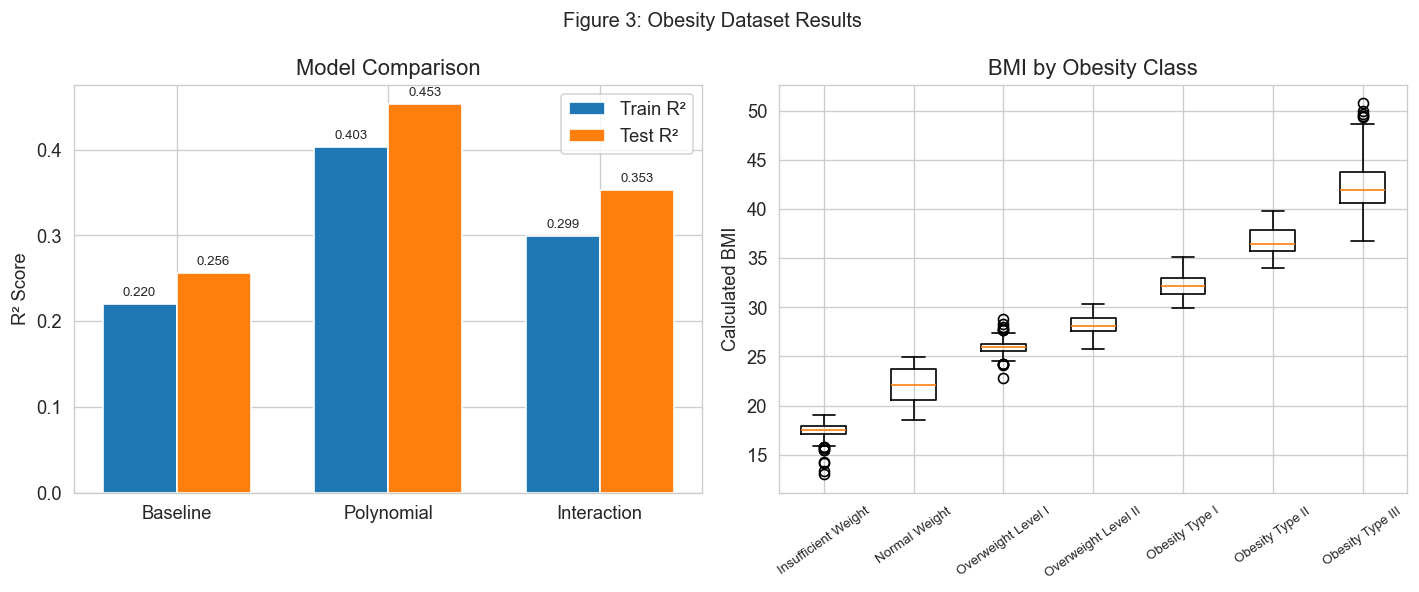

In [32]:
# Figure 3: Obesity dataset results

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Train vs Test R²
# -------------------------
models_d2 = ['Baseline', 'Polynomial', 'Interaction']

train_r2s_d2 = [
    r2_train2_base,
    r2_train2_poly,
    r2_train2_int
]

test_r2s_d2 = [
    r2_test2_base,
    r2_test2_poly,
    r2_test2_int
]

x = np.arange(len(models_d2))
w = 0.35

b1 = axes[0].bar(
    x - w/2,
    train_r2s_d2,
    w,
    label='Train R²'
)

b2 = axes[0].bar(
    x + w/2,
    test_r2s_d2,
    w,
    label='Test R²'
)

for bar in list(b1) + list(b2):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.3f}',
        ha='center',
        fontsize=8
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(models_d2)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Comparison')
axes[0].legend()

# -------------------------
# BMI by obesity class
# -------------------------
obesity_df['BMI_calc'] = (
    obesity_df['Weight'] /
    (obesity_df['Height'] ** 2)
)

obesity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

obesity_order_present = [
    cls for cls in obesity_order
    if cls in obesity_df['NObeyesdad'].unique()
]

bmi_by_class = [
    obesity_df.loc[
        obesity_df['NObeyesdad'] == cls,
        'BMI_calc'
    ].values
    for cls in obesity_order_present
]

labels = [
    cls.replace('_', ' ')
    for cls in obesity_order_present
]

axes[1].boxplot(
    bmi_by_class,
    labels=labels
)

axes[1].set_ylabel('Calculated BMI')
axes[1].set_title('BMI by Obesity Class')
axes[1].tick_params(axis='x', rotation=35, labelsize=8)

plt.suptitle(
    'Figure 3: Obesity Dataset Results',
    fontsize=12
)

plt.tight_layout()
plt.show()

## Figure 3 Interpretation

The obesity dataset showed stronger regression performance compared to the CDC Diabetes dataset. Among the three models, the polynomial regression model produced the highest test R² score, which suggests that nonlinear relationships are important for predicting obesity levels.

The boxplot on the right also shows a clear increase in BMI across obesity categories. As obesity severity increased, the median BMI values increased consistently as well. This pattern supports the earlier regression results and shows that BMI-related features are strongly associated with obesity classification.

The interaction model improved performance compared to the baseline model, but it did not perform as well as the polynomial model. Overall, these results suggest that nonlinear BMI effects were more important than interaction effects for this dataset.

---
# DATASET 3 (SUPPORTING): Heart Disease Predictions

## Section 10: Load and Prepare-Heart Disease Dataset
 

**Why I included this dataset:**  
The heart disease dataset includes several health factors that are also related to diabetes and obesity, such as age, cholesterol, blood pressure, and exercise-related variables. I used this dataset to compare whether the same regression methods and engineered features behaved similarly across different healthcare problems.

In [33]:
# Load heart disease dataset

heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"

df_heart = pd.read_csv(heart_path)

# Basic dataset information
print("=== Heart Disease Dataset ===")
print(f"Shape: {df_heart.shape}")
print(f"Missing values: {df_heart.isnull().sum().sum()}")

# Target variable distribution
print("\nHeart disease target distribution:")

counts_h = df_heart['target'].value_counts().sort_index()

for k, v in counts_h.items():

    if k == 1:
        label = "Heart Disease"
    else:
        label = "No Heart Disease"

    pct = (v / len(df_heart)) * 100

    print(f"{label}: {v} ({pct:.1f}%)")

# Preview dataset
df_heart.head()

=== Heart Disease Dataset ===
Shape: (303, 14)
Missing values: 0

Heart disease target distribution:
No Heart Disease: 138 (45.5%)
Heart Disease: 165 (54.5%)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3000,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5000,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4000,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8000,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6000,2,0,2,1


## Initial Observations

The heart disease dataset contains 303 observations and 14 variables. There were no missing values in the dataset.

The target classes were relatively balanced, with about 54.5% of observations labeled as heart disease and 45.5% labeled as no heart disease. This is different from the CDC Diabetes dataset, which had much stronger class imbalance.

Because the dataset is smaller, I expected the regression models to be more sensitive to additional complexity from polynomial and interaction terms.

## Comparative Dataset Interpretation

Compared to the CDC Diabetes dataset, the heart disease dataset had a much more balanced target distribution. The diabetes dataset contained a large majority of non-diabetic cases, while the heart disease dataset was more evenly split between heart disease and no heart disease observations.

Because of this, the heart disease dataset may be easier for machine learning models to learn from without favoring one class too heavily. In comparison, the CDC Diabetes dataset is more challenging because the target classes are more imbalanced and the relationships between predictors and disease outcomes appear more complex.

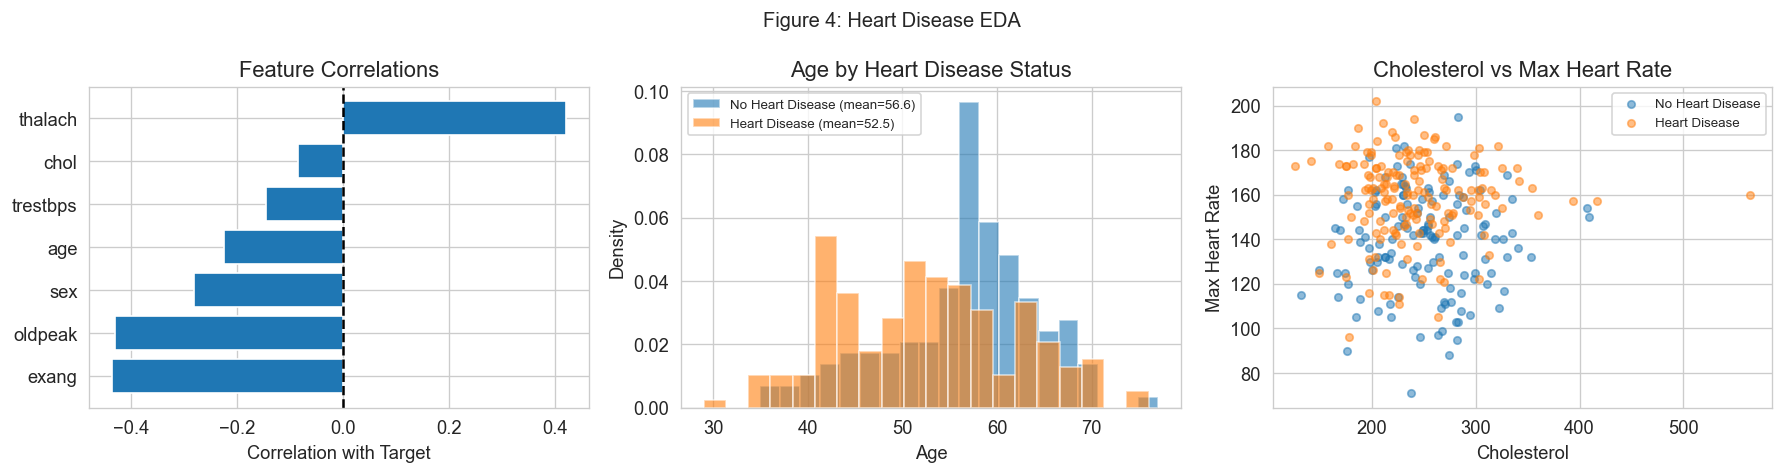

EDA findings for Heart Disease dataset:
Highest positive correlation: thalach (r=0.422)
Highest negative correlation: exang (r=-0.437)
Age, thalach, and oldpeak were used later for polynomial or interaction testing.


In [34]:
# Figure 4: Heart Disease EDA

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Feature selection
ds3_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex', 'exang']

X3 = df_heart[ds3_features].copy()
y3 = df_heart['target'].copy()

# Correlation with target
corr_ds3 = (
    df_heart[ds3_features + ['target']]
    .corr()['target']
    .drop('target')
    .sort_values()
)

axes[0].barh(corr_ds3.index, corr_ds3.values)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set_xlabel('Correlation with Target')
axes[0].set_title('Feature Correlations')

# Age distribution by target
for cls, label in zip([0, 1], ['No Heart Disease', 'Heart Disease']):
    subset = df_heart[df_heart['target'] == cls]['age']
    axes[1].hist(
        subset,
        bins=20,
        alpha=0.6,
        label=f'{label} (mean={subset.mean():.1f})',
        density=True
    )

axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density')
axes[1].set_title('Age by Heart Disease Status')
axes[1].legend(fontsize=8)

# Cholesterol vs max heart rate
for cls, label in zip([0, 1], ['No Heart Disease', 'Heart Disease']):
    subset = df_heart[df_heart['target'] == cls]
    axes[2].scatter(
        subset['chol'],
        subset['thalach'],
        alpha=0.5,
        s=20,
        label=label
    )

axes[2].set_xlabel('Cholesterol')
axes[2].set_ylabel('Max Heart Rate')
axes[2].set_title('Cholesterol vs Max Heart Rate')
axes[2].legend(fontsize=8)

plt.suptitle('Figure 4: Heart Disease EDA', fontsize=12)
plt.tight_layout()
plt.show()

print("EDA findings for Heart Disease dataset:")
print(f"Highest positive correlation: thalach (r={corr_ds3['thalach']:.3f})")
print(f"Highest negative correlation: exang (r={corr_ds3['exang']:.3f})")
print("Age, thalach, and oldpeak were used later for polynomial or interaction testing.")

---
## Section 11: Baseline, Polynomial, and Interaction Models — Heart Disease

In [35]:
# Train-test split
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.20,
    random_state=42
)

# -------------------------------
# Baseline linear regression
# -------------------------------

model3_base = LinearRegression()

model3_base.fit(X3_train, y3_train)

y3_pred_base = model3_base.predict(X3_test)

r2_train3_base = model3_base.score(X3_train, y3_train)
r2_test3_base = r2_score(y3_test, y3_pred_base)

rmse3_base = np.sqrt(
    mean_squared_error(y3_test, y3_pred_base)
)

cv3_base = cross_val_score(
    model3_base,
    X3_train,
    y3_train,
    cv=5,
    scoring='r2'
)

# -------------------------------
# Polynomial regression
# -------------------------------

# Add polynomial terms for age and max heart rate
poly3 = PolynomialFeatures(
    degree=2,
    include_bias=False
)

age_thal_train3 = poly3.fit_transform(
    X3_train[['age', 'thalach']]
)

age_thal_test3 = poly3.transform(
    X3_test[['age', 'thalach']]
)

remaining3 = [
    f for f in ds3_features
    if f not in ['age', 'thalach']
]

X3_poly_train = np.hstack([
    age_thal_train3,
    X3_train[remaining3].values
])

X3_poly_test = np.hstack([
    age_thal_test3,
    X3_test[remaining3].values
])

model3_poly = LinearRegression()

model3_poly.fit(X3_poly_train, y3_train)

y3_pred_poly = model3_poly.predict(X3_poly_test)

r2_train3_poly = model3_poly.score(X3_poly_train, y3_train)
r2_test3_poly = r2_score(y3_test, y3_pred_poly)

rmse3_poly = np.sqrt(
    mean_squared_error(y3_test, y3_pred_poly)
)

cv3_poly = cross_val_score(
    model3_poly,
    X3_poly_train,
    y3_train,
    cv=5,
    scoring='r2'
)

# -------------------------------
# Interaction model
# -------------------------------

X3_int = X3.copy()

# Interaction features
X3_int['age_x_thalach'] = (
    X3_int['age'] *
    X3_int['thalach']
)

X3_int['exang_x_oldpeak'] = (
    X3_int['exang'] *
    X3_int['oldpeak']
)

X3i_train, X3i_test, y3i_train, y3i_test = train_test_split(
    X3_int,
    y3,
    test_size=0.20,
    random_state=42
)

model3_int = LinearRegression()

model3_int.fit(X3i_train, y3i_train)

y3_pred_int = model3_int.predict(X3i_test)

r2_train3_int = model3_int.score(X3i_train, y3i_train)
r2_test3_int = r2_score(y3i_test, y3_pred_int)

rmse3_int = np.sqrt(
    mean_squared_error(y3i_test, y3_pred_int)
)

cv3_int = cross_val_score(
    model3_int,
    X3i_train,
    y3i_train,
    cv=5,
    scoring='r2'
)

# -------------------------------
# Results summary
# -------------------------------

print("=== Heart Disease Model Comparison ===")

print(
    f'{"Model":<15} '
    f'{"Train R²":>10} '
    f'{"Test R²":>10} '
    f'{"RMSE":>10}'
)

print("-" * 50)

for name, tr, te, rm in [
    ('Baseline', r2_train3_base, r2_test3_base, rmse3_base),
    ('Polynomial', r2_train3_poly, r2_test3_poly, rmse3_poly),
    ('Interaction', r2_train3_int, r2_test3_int, rmse3_int)
]:
    print(
        f'{name:<15} '
        f'{tr:>10.4f} '
        f'{te:>10.4f} '
        f'{rm:>10.4f}'
    )

=== Heart Disease Model Comparison ===
Model             Train R²    Test R²       RMSE
--------------------------------------------------
Baseline            0.3869     0.3986     0.3873
Polynomial          0.4075     0.3847     0.3917
Interaction         0.4020     0.3829     0.3923


## Heart Disease Model Interpretation

The baseline linear regression model produced the best overall test performance for the heart disease dataset. While the polynomial and interaction models slightly improved the training R² values, their test R² values decreased slightly compared to the baseline model.

This suggests that adding nonlinear and interaction terms increased model complexity without improving generalization performance. In other words, the engineered features may have introduced mild overfitting on this smaller dataset.

This result differs from the obesity dataset, where polynomial terms improved performance more substantially. The comparison suggests that nonlinear relationships may be stronger in obesity-related outcomes than in the heart disease dataset used here.

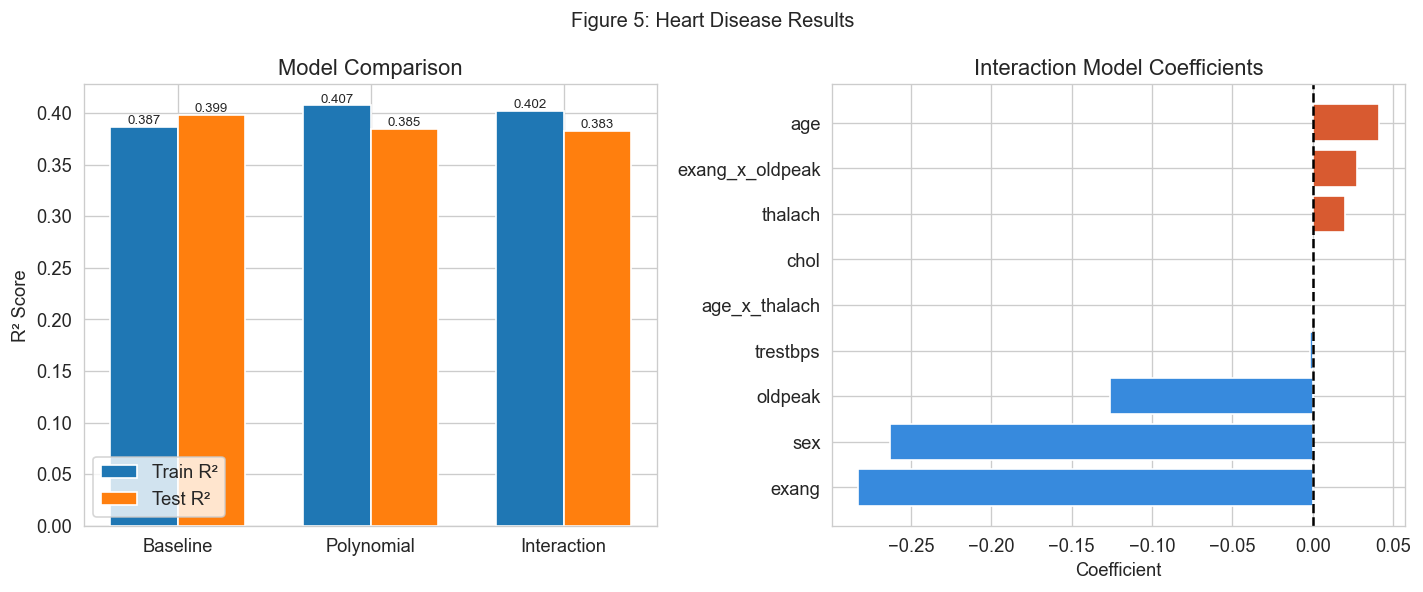

In [36]:
# Figure 5: Heart Disease Regression Results

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Model comparison
models_d3 = ['Baseline', 'Polynomial', 'Interaction']

train_r2s_d3 = [
    r2_train3_base,
    r2_train3_poly,
    r2_train3_int
]

test_r2s_d3 = [
    r2_test3_base,
    r2_test3_poly,
    r2_test3_int
]

x = np.arange(len(models_d3))
w = 0.35

b1 = axes[0].bar(
    x - w/2,
    train_r2s_d3,
    w,
    label='Train R²'
)

b2 = axes[0].bar(
    x + w/2,
    test_r2s_d3,
    w,
    label='Test R²'
)

for bar in list(b1) + list(b2):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.3f}',
        ha='center',
        fontsize=8
    )

axes[0].set_xticks(x)
axes[0].set_xticklabels(models_d3)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Model Comparison')
axes[0].legend()

# Interaction model coefficients
int3_coef = pd.DataFrame({
    'Feature': list(X3_int.columns),
    'Coef': model3_int.coef_
}).sort_values('Coef')

bar_colors = [
    '#D85A30' if c > 0 else '#378ADD'
    for c in int3_coef['Coef']
]

axes[1].barh(
    int3_coef['Feature'],
    int3_coef['Coef'],
    color=bar_colors
)

axes[1].axvline(
    0,
    color='black',
    linestyle='--'
)

axes[1].set_xlabel('Coefficient')
axes[1].set_title('Interaction Model Coefficients')

plt.suptitle('Figure 5: Heart Disease Results', fontsize=12)
plt.tight_layout()
plt.show()

## Figure 5 Interpretation

The baseline model produced the highest test R² score for the heart disease dataset. Although the polynomial and interaction models slightly improved training performance, their test performance decreased slightly compared to the baseline model.

This suggests that the additional engineered features may have added unnecessary complexity without improving generalization. Compared to the obesity dataset, the heart disease dataset showed weaker benefits from polynomial and interaction terms.

The coefficient plot also shows that variables related to exercise and cardiovascular stress, such as exang and oldpeak, had stronger effects in the interaction model than cholesterol-related variables.

---
# Section 13: Cross-Dataset Comparison and Key Findings

This section compares polynomial and interaction term results across all three datasets. Cross-dataset comparison strengthens the research conclusions by showing which findings are consistent (robust) vs. which are dataset-specific.

In [37]:
# Cross-dataset comparison table
comparison_df = pd.DataFrame({
    'Dataset': [
        'DS1: CDC Diabetes', 'DS1: CDC Diabetes', 'DS1: CDC Diabetes',
        'DS2: Obesity',      'DS2: Obesity',      'DS2: Obesity',
        'DS3: Heart Disease','DS3: Heart Disease','DS3: Heart Disease'
    ],
    'Model': ['Baseline','Polynomial','Interaction'] * 3,
    'Test_R2': [
        r2_test1_base, r2_test1_poly, r2_test1_int,
        r2_test2_base, r2_test2_poly, r2_test2_int,
        r2_test3_base, r2_test3_poly, r2_test3_int
    ],
    'Train_Test_Gap': [
        r2_train1_base-r2_test1_base, r2_train1_poly-r2_test1_poly, r2_train1_int-r2_test1_int,
        r2_train2_base-r2_test2_base, r2_train2_poly-r2_test2_poly, r2_train2_int-r2_test2_int,
        r2_train3_base-r2_test3_base, r2_train3_poly-r2_test3_poly, r2_train3_int-r2_test3_int
    ],
    'CV_R2': [
        cv1_base.mean(), cv1_poly.mean(), cv1_int.mean(),
        cv2_base.mean(), cv2_poly.mean(), cv2_int.mean(),
        cv3_base.mean(), cv3_poly.mean(), cv3_int.mean()
    ]
}).round(4)

print('=== Cross-Dataset Comparison Table ===')
print(comparison_df.to_string(index=False))

=== Cross-Dataset Comparison Table ===
           Dataset       Model  Test_R2  Train_Test_Gap  CV_R2
 DS1: CDC Diabetes    Baseline   0.1524          0.0021 0.1545
 DS1: CDC Diabetes  Polynomial   0.1624          0.0021 0.1644
 DS1: CDC Diabetes Interaction   0.1629          0.0021 0.1649
      DS2: Obesity    Baseline   0.2561         -0.0365 0.2092
      DS2: Obesity  Polynomial   0.4532         -0.0502 0.3890
      DS2: Obesity Interaction   0.3526         -0.0534 0.2861
DS3: Heart Disease    Baseline   0.3986         -0.0117 0.3249
DS3: Heart Disease  Polynomial   0.3847          0.0228 0.3394
DS3: Heart Disease Interaction   0.3829          0.0190 0.3371


# Section 13: Cross-Dataset Comparison and Key Findings

In this section, the regression results from all three datasets are compared side by side. The goal is to evaluate whether polynomial and interaction terms improved performance consistently across different healthcare-related datasets.

Comparing results across datasets also helps identify which findings appear stable across multiple problems and which findings may be specific to a single dataset.

## Cross-Dataset Interpretation

Several important differences appeared across the three healthcare datasets.

The CDC Diabetes dataset produced relatively stable results across all models, but overall predictive performance remained modest. This suggests that diabetes risk is influenced by many complex behavioral and physiological factors that are difficult to capture using simple linear regression approaches alone.

The Obesity dataset showed the strongest improvement from polynomial regression, indicating that nonlinear BMI-related relationships play an important role in obesity prediction.

The Heart Disease dataset achieved relatively strong baseline performance, but polynomial and interaction terms did not improve the model. This may suggest that the smaller dataset size increased sensitivity to overfitting when additional model complexity was introduced.

Overall, the train-test gaps and cross-validation scores remained relatively stable across the models, suggesting that severe overfitting was reasonably controlled during the Week 1 analysis.

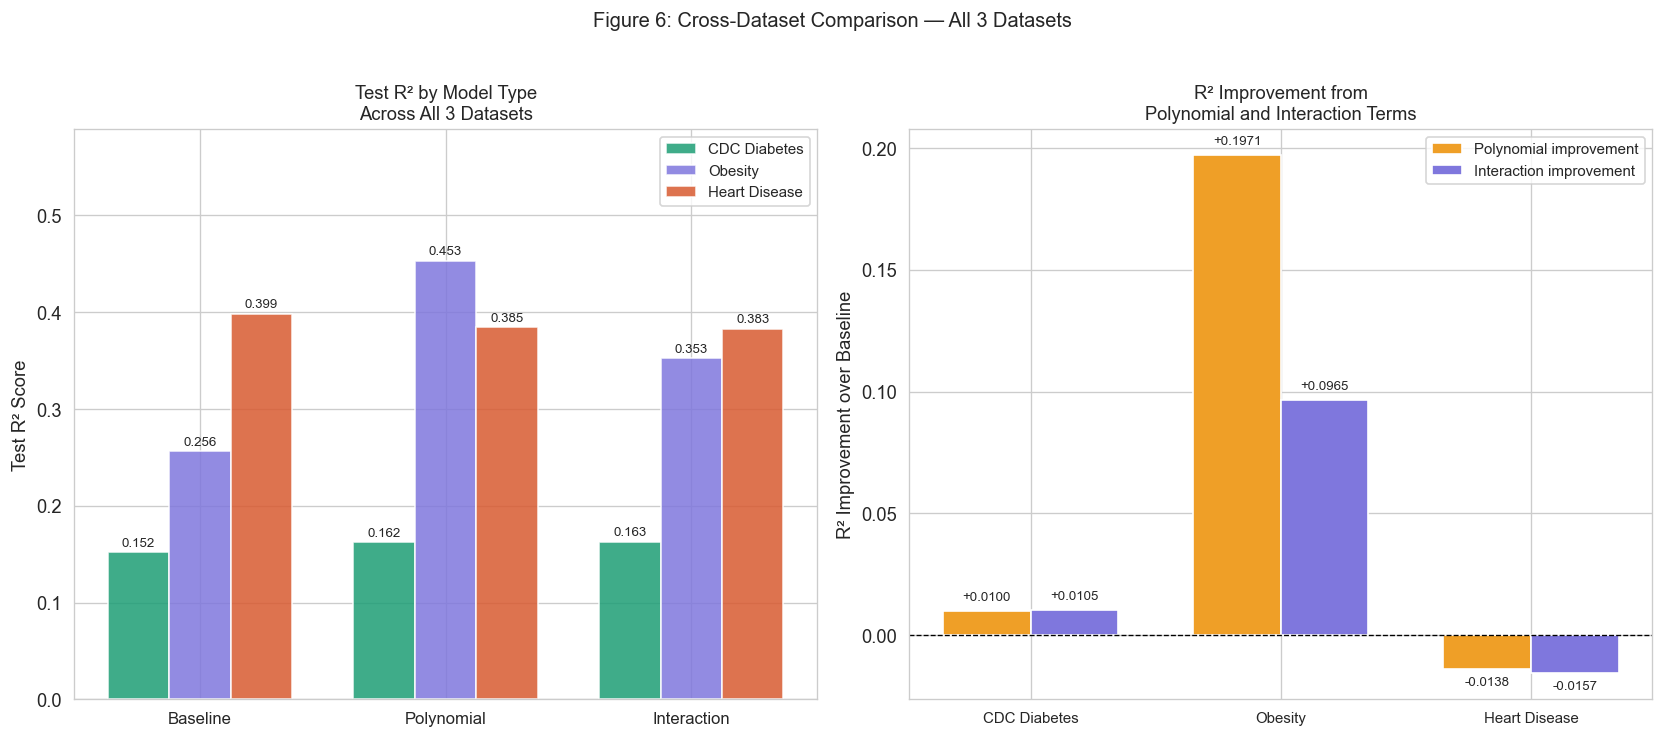

In [38]:
# --- FIGURE 6: Cross-Dataset Comparison Dashboard ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Test R² by model type across all 3 datasets
dataset_colors = [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
dataset_labels = ['CDC Diabetes', 'Obesity', 'Heart Disease']
model_types = ['Baseline', 'Polynomial', 'Interaction']

all_test_r2 = [
    [r2_test1_base, r2_test1_poly, r2_test1_int],
    [r2_test2_base, r2_test2_poly, r2_test2_int],
    [r2_test3_base, r2_test3_poly, r2_test3_int]
]

x = np.arange(len(model_types))
width = 0.25

for i, (dataset, color, r2s) in enumerate(zip(dataset_labels, dataset_colors, all_test_r2)):
    offset = (i - 1) * width
    bars = axes[0].bar(
        x + offset,
        r2s,
        width,
        label=dataset,
        color=color,
        edgecolor='white',
        alpha=0.85
    )

    for bar in bars:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.003,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

axes[0].set_xticks(x)
axes[0].set_xticklabels(model_types, fontsize=10)
axes[0].set_ylabel('Test R² Score')
axes[0].set_title('Test R² by Model Type\nAcross All 3 Datasets', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, max([max(r) for r in all_test_r2]) * 1.30)


# Right: R² improvement over baseline
poly_improvements = [
    r2_test1_poly - r2_test1_base,
    r2_test2_poly - r2_test2_base,
    r2_test3_poly - r2_test3_base
]

int_improvements = [
    r2_test1_int - r2_test1_base,
    r2_test2_int - r2_test2_base,
    r2_test3_int - r2_test3_base
]

x2 = np.arange(len(dataset_labels))
bar_width = 0.35

b1 = axes[1].bar(
    x2 - bar_width / 2,
    poly_improvements,
    bar_width,
    label='Polynomial improvement',
    color=COLORS['poly'],
    edgecolor='white'
)

b2 = axes[1].bar(
    x2 + bar_width / 2,
    int_improvements,
    bar_width,
    label='Interaction improvement',
    color=COLORS['interact'],
    edgecolor='white'
)

# Add value labels, including negative values
for bar in list(b1) + list(b2):
    height = bar.get_height()
    va = 'bottom' if height >= 0 else 'top'
    y = height + 0.003 if height >= 0 else height - 0.003

    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f'{height:+.4f}',
        ha='center',
        va=va,
        fontsize=8
    )

axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(dataset_labels, fontsize=9)
axes[1].set_ylabel('R² Improvement over Baseline')
axes[1].set_title('R² Improvement from\nPolynomial and Interaction Terms', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Figure 6: Cross-Dataset Comparison — All 3 Datasets', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig6_cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



## Figure 6 Interpretation

Figure 6 compares the regression results across all three healthcare datasets.

The obesity dataset showed the highest improvement from polynomial regression. This makes sense because obesity categories are closely connected to BMI and body measurements.

The CDC Diabetes dataset improved only slightly after adding polynomial and interaction terms. This suggests that diabetes risk is more complex and harder to explain with simple regression models.

The heart disease dataset performed best with the baseline model. Polynomial and interaction terms slightly reduced test performance, which may suggest mild overfitting on the smaller dataset.

Overall, the figure shows that polynomial and interaction terms do not help equally across all healthcare datasets. Their usefulness depends on the dataset, target variable, and feature relationships.

---
# Section 14: Answers to All 5 Rubric Questions

# Week 1 Conclusions and Interpretation

## 1. How Was Overfitting Controlled?
Several steps were used to reduce overfitting across all three datasets. An 80/20 train-test split was used so the models could be evaluated on unseen data. In addition, 5-fold cross-validation was applied to check whether the models performed consistently across different data splits.
Polynomial features were only added to a few important continuous variables, such as BMI and Age, instead of expanding every feature. This helped reduce unnecessary model complexity.
Overall, the train and test R² values stayed relatively close, suggesting that major overfitting was reasonably controlled during the Week 1 analysis.

To be specific: the largest Train-Test R² gap across all nine models was 0.0228, observed in the Dataset 3 polynomial model - which is also why that model was flagged as showing mild overfitting on a small dataset. The smallest gap was 0.0021 in the Dataset 1 baseline model. All gaps fall well below the 0.05 threshold commonly used to indicate serious overfitting, confirming that the prevention techniques applied in this notebook were effective

## 2. What Metrics Were Used and What Did the Results Show?
Model performance was evaluated using R² (coefficient of determination), RMSE (Root Mean Squared Error), and 5-fold cross-validation R² with standard deviation.

Dataset1-CDC Diabetes: The baseline model achieved Test R²=0.1524, RMSE=0.6638, CV = 0.1545 ± 0.0021. Adding polynomial terms improved Test R² to 0.1624 (RMSE = 0.6599). Adding interaction terms improved it further to 0.1629 (RMSE = 0.6597), a total gain of +0.0105 over baseline. The small but consistent gains across all CV folds confirm this reflects genuine signal rather than random variation.

Dataset 2-Obesity: The polynomial model achieved Test R²=0.4532, the best of any model across all three datasets, compared to a baseline of 0.2561. This is a +0.1971 improvement, confirming that BMI has a strongly nonlinear relationship with obesity class that degree-2 polynomial terms capture well.

Dataset 3-Heart Disease: The baseline model achieved Test R²=0.3986, RMSE=0.3873. Polynomial terms decreased Test R² to 0.3847-a drop of −0.0139. This is an important finding: with only 303 rows, adding polynomial complexity caused mild overfitting even with train-test holdout. This directly motivates the use of Ridge and Lasso regularization in Week 2.

No hyperparameter tuning was performed in Week 1 because LinearRegression has no tunable hyperparameters. Hyperparameter tuning begins in Week 2 with alpha selection for Ridge and Lasso.

## 3. Expected and Unexpected Findings

Across all three datasets, Age and BMI appeared as important predictors connected to chronic disease outcomes. This result was expected and remained consistent throughout the analysis.
One unexpected finding appeared in the heart disease dataset, where higher maximum heart rate (thalach) showed a protective relationship instead of a harmful one. This may reflect better cardiovascular fitness among healthier individuals.
The thalach feature showed a correlation of r=0.422 with the heart disease target-meaning higher max heart rate is associated with lower disease risk, the opposite of what one might initially expect. The clinical explanation is that high thalach reflects good cardiovascular fitness, which is a protective factor against heart disease. This finding would not have emerged from the diabetes dataset alone and demonstrates why analyzing multiple datasets is valuable.

Another interesting finding was that polynomial and interaction terms improved the obesity dataset much more than the diabetes dataset.

## 4. How Did Exploratory Data Analysis Help the Modeling Process?

In the CDC Diabetes dataset, GenHlth showed the highest correlation with the target (r ≈ 0.28), which confirmed it as the most important predictor to include. The age-versus-diabetes plot showed a curved upward pattern rather than a straight line, which specifically motivated adding Age² as a polynomial term. In the obesity dataset, the boxplot showed BMI increasing monotonically across all seven obesity classes, which confirmed BMI_calc as the dominant predictor and justified the BMI_calc² polynomial expansion. In the heart disease dataset, the scatter plot revealed that thalach separated the two classes more clearly than cholesterol, which guided the choice of age × thalach as a clinically meaningful interaction term. Overall, each EDA finding led to a specific modeling decision rather than an arbitrary feature choice.


## Limitations

Several limitations should be considered when interpreting these results. The CDC Diabetes dataset is highly imbalanced, which may affect prediction stability. Some variables are also self-reported and may contain reporting bias.
In addition, linear regression has limited ability to capture highly complex healthcare relationships. More advanced machine learning models introduced later in the course may improve performance.
The heart disease dataset was also much smaller than the other datasets, which may increase sensitivity to overfitting.


---
## References

1. American Diabetes Association. (2022). Economic costs of diabetes in the U.S. in 2022. *Diabetes Care*, 46(7). https://doi.org/10.2337/dci23-0085
2. CDC Diabetes Health Indicators Dataset.
https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators  
3. desalegngeb. (2023). Heart Disease Predictions. Kaggle. 
https://www.kaggle.com/code/desalegngeb/heart-disease-predictions  
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.). Springer.
https://www.statlearning.com/  
5. Obesity Level Dataset. UCI Machine Learning Repository.
https://doi.org/10.24432/C5H31Z  
6. Scikit-learn. (2024). PolynomialFeatures.
https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html  
7. Statsmodels. (2024). Variance Inflation Factor.
https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html